## Cell 0: Create 5-Run Dataset (Run Once)

Splits run 3 (log_20260309_141435.414) at its temporal midpoint into partA and partB.
dry_dirt_track appears in both halves (394 windows in partA, 258 in partB), making it
evaluable in 2/5 LORO-CV folds instead of 0/4.

The cell is idempotent: if dataset_A_pruned_5run.csv already exists it is left unchanged.

In [2]:
RUN3_ID = "log_20260309_141435.414"
_out = PROJECT_ROOT / "data" / "processed" / "dataset_A_pruned_5run.csv"

if _out.exists():
    print(f"Already exists, skipping split: {_out}")
else:
    _df_orig = pd.read_csv(
        PROJECT_ROOT / "data" / "processed" / "dataset_A_pruned.csv"
    )

    _run3 = _df_orig[_df_orig["run_id"] == RUN3_ID].sort_values("t_start")
    _midpoint = _run3["t_start"].median()

    _df_orig.loc[
        (_df_orig["run_id"] == RUN3_ID) & (_df_orig["t_start"] <= _midpoint),
        "run_id",
    ] = "log_20260309_141435.414_partA"

    _df_orig.loc[
        (_df_orig["run_id"] == RUN3_ID) & (_df_orig["t_start"] > _midpoint),
        "run_id",
    ] = "log_20260309_141435.414_partB"

    _df_orig.to_csv(_out, index=False)

    print(f"Saved: {_out}")
    print("\nRun × label distribution after split:")
    print(
        _df_orig.groupby("run_id")["label"]
        .value_counts()
        .unstack(fill_value=0)
        .to_string()
    )


Already exists, skipping split: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/dataset_A_pruned_5run.csv


In [3]:
_df_orig = pd.read_csv(
       PROJECT_ROOT / "data" / "processed" / "dataset_A_pruned_5run.csv"
    )
print("\nRun × label distribution after split:")
print(
    _df_orig.groupby("run_id")["label"]
    .value_counts()
    .unstack(fill_value=0)
    .to_string()
)


Run × label distribution after split:
label                          cobblestone  dry_dirt_track  grass  muddy_dirt_track  smooth_terrain
run_id                                                                                             
log_20260223_142511.490                  0               0     26                99             168
log_20260226_102148.990                  0               0     44                46              55
log_20260309_141435.414_partA            0             394     68                 0             202
log_20260309_141435.414_partB           37             258    248                 0             121
log_20260326_120021.508                318               0    102                 0             160


# Terrain Baselines with Strict LORO-CV

This notebook runs baseline supervised terrain classification experiments with IMU + odometry features using a strict leave-one-run-out cross-validation (LORO-CV) protocol.

Why this split is mandatory for this dataset:
- Windows have 50% overlap, so adjacent windows are highly correlated.
- Any random or stratified window split leaks correlated windows across train/test.
- The unit of independence is the run (trajectory collected on a different day).
- LORO-CV is the only defensible strategy here for deployment-like generalization.

Hard rules enforced in this notebook:
- `KNOWN_DEGENERATE` is the single source of truth for fold-level degenerate flags.
- `LabelEncoder` is fit inside each fold on train labels only.
- `StandardScaler` is always inside the pipeline.
- Unknown labels are rejected (fail fast).

In [ ]:
from __future__ import annotations

import json
import warnings
from datetime import datetime, timezone
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "xgboost is required for this notebook. Install it in the ricbot kernel before running."
    ) from exc

# Project bootstrap (same pattern as prior notebooks)
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RANDOM_STATE = 42
USE_TOP_MI = False
N_TOP_MI = 25
RUN_IMBALANCE_COMPARISON = True
RUN_OPTIONAL_TUNING = True
SAVE_MODELS = False
RUN_RETRAIN_BEST = True

# Robustness and ablation controls
ENABLE_FEATURE_ABLATIONS = True
ENABLE_FOLD_LOCAL_TOP_MI = True
MI_NEIGHBORS = 5
N_PERMUTATION_REPEATS = 8
SPEED_TVD_WARN_THRESHOLD = 0.35
TRAIN_COUNT_LOW_THRESHOLD = 80
TRAIN_COUNT_CRITICAL_THRESHOLD = 30
MIN_WORST_FOLD_MACRO_F1 = 0.60

location = "Farm"

REPORTS_DIR = PROJECT_ROOT / "reports" / "models" / location
MODELS_DIR = PROJECT_ROOT / "models" / location
RESULTS_DIR = PROJECT_ROOT / "results" / location

LABEL_COL = "label"
RUN_COL = "run_id"
ID_COLS = [
    "window_id",
    "run_id",
    "segment_id",
    "label",
    "t_start",
    "t_end",
    "n_samples",
]
# 5 classes across 5 runs after splitting run 3
LABEL_ORDER = [
    "cobblestone",
    "dry_dirt_track",
    "grass",
    "muddy_dirt_track",
    "smooth_terrain",
]

# With the 5-run split, no test fold contains a class missing from training.
# Keep this explicit map empty and let Cell 2 enforce it strictly.
KNOWN_DEGENERATE = {}

# cobblestone speed confound is reduced after the split.
# Both partB and run 4 were driven at lower, more consistent speeds
# compared to the original full run 3 which mixed high and low speed.
# Flag for thesis but less severe than before.
KNOWN_CONFOUNDED = {
    "log_20260309_141435.414_partB": {
        "cobblestone": "train=run4 only, test=partB (same original session, consistent speed)",
    },
    "log_20260326_120021.508": {
        "cobblestone": "train=partB only, test=run4 (different session)",
    },
}

CLASS_SAMPLE_WARN_THRESHOLD = 30

for out_dir in [REPORTS_DIR, MODELS_DIR, RESULTS_DIR]:
    out_dir.mkdir(parents=True, exist_ok=True)

print("Configuration loaded")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RUN_IMBALANCE_COMPARISON: {RUN_IMBALANCE_COMPARISON}")
print(f"RUN_OPTIONAL_TUNING: {RUN_OPTIONAL_TUNING}")
print(f"SAVE_MODELS: {SAVE_MODELS}")
print(f"RUN_RETRAIN_BEST: {RUN_RETRAIN_BEST}")
print(f"ENABLE_FEATURE_ABLATIONS: {ENABLE_FEATURE_ABLATIONS}")
print(f"ENABLE_FOLD_LOCAL_TOP_MI: {ENABLE_FOLD_LOCAL_TOP_MI}")
from src.evaluation import (
    compute_fold_metrics,
    fmt_mean_std,
    make_base_models,
    row_normalize,
    summarize_group,
)


Configuration loaded
PROJECT_ROOT: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
RUN_IMBALANCE_COMPARISON: True
RUN_OPTIONAL_TUNING: True
SAVE_MODELS: False
RUN_RETRAIN_BEST: True
ENABLE_FEATURE_ABLATIONS: True
ENABLE_FOLD_LOCAL_TOP_MI: True


## Cell 2: Load Data and Define Feature Sets

This cell validates strict schema/label assumptions, builds all-features and top-MI feature sets, and prints the run-level fold preview used by LORO-CV.

In [ ]:
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / location / "dataset_A_pruned_5run.csv"
TOP_MI_PATH = PROJECT_ROOT / "data" / "processed" / location / "top_mi_features.json"

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")
if not TOP_MI_PATH.exists():
    raise FileNotFoundError(f"Missing MI feature list: {TOP_MI_PATH}")

df = pd.read_csv(DATASET_PATH)

with TOP_MI_PATH.open("r", encoding="utf-8") as f:
    top_mi_raw = json.load(f)

if isinstance(top_mi_raw, dict):
    # Accept either {feature: score} or a keyed payload containing a list.
    if "top_features" in top_mi_raw and isinstance(top_mi_raw["top_features"], list):
        top_mi_features = list(top_mi_raw["top_features"])
    else:
        top_mi_features = list(top_mi_raw.keys())
elif isinstance(top_mi_raw, list):
    top_mi_features = list(top_mi_raw)
else:
    raise ValueError("Unsupported top_mi_features.json structure. Expected list or dict.")

missing_id_cols = [c for c in ID_COLS if c not in df.columns]
if missing_id_cols:
    raise KeyError(f"Missing ID columns in dataset: {missing_id_cols}")

if LABEL_COL not in df.columns or RUN_COL not in df.columns:
    raise KeyError(f"Dataset must contain {LABEL_COL} and {RUN_COL}.")

labels_found = sorted(df[LABEL_COL].astype(str).unique().tolist())
if set(labels_found) != set(LABEL_ORDER):
    raise ValueError(
        "Strict label check failed. Expected labels: "
        f"{sorted(LABEL_ORDER)} | Found: {labels_found}"
    )

run_ids = sorted(df[RUN_COL].astype(str).unique().tolist())
if len(run_ids) < 2:
    raise ValueError("LORO-CV requires at least two unique runs.")

feature_cols_all = [c for c in df.columns if c not in ID_COLS]
feature_cols_mi = [c for c in top_mi_features if c in feature_cols_all]
if N_TOP_MI is not None and N_TOP_MI > 0:
    feature_cols_mi = feature_cols_mi[:N_TOP_MI]
if not feature_cols_mi:
    raise ValueError("No overlap between top_mi_features.json and dataset columns.")

print(f"Dataset shape: {df.shape}")
print(f"Feature count (all pruned): {len(feature_cols_all)}")
print(f"Feature count (top MI): {len(feature_cols_mi)}")
print("\nLabel distribution:")
print(df[LABEL_COL].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int).to_string())
print("\nWindows per run:")
print(df[RUN_COL].value_counts().sort_index().to_string())

SPEED_COL_CANDIDATES = ["odom_mean_speed", "net_speed"]
speed_col = next((c for c in SPEED_COL_CANDIDATES if c in df.columns), None)
speed_bin_labels: list[str] = []
if speed_col is not None:
    q_edges = df[speed_col].quantile([0.0, 1.0 / 3.0, 2.0 / 3.0, 1.0]).to_numpy(dtype=float)
    q_edges = np.unique(q_edges)
    if len(q_edges) < 4:
        # Fallback if quantiles collapse due to duplicated values.
        q_edges = np.linspace(df[speed_col].min(), df[speed_col].max(), 4)
    if np.unique(q_edges).shape[0] < 2:
        warnings.warn(f"Speed column '{speed_col}' has near-constant values; speed-bin diagnostics disabled.")
        speed_col = None
    else:
        # Ensure strictly increasing bin edges.
        q_edges = np.maximum.accumulate(q_edges)
        for idx in range(1, len(q_edges)):
            if q_edges[idx] <= q_edges[idx - 1]:
                q_edges[idx] = q_edges[idx - 1] + 1e-9
        speed_bin_labels = [f"bin{i + 1}" for i in range(len(q_edges) - 1)]
        df["speed_bin"] = pd.cut(
            df[speed_col],
            bins=q_edges,
            labels=speed_bin_labels,
            include_lowest=True,
            duplicates="drop",
        )
        print(f"\nSpeed diagnostics enabled using column: {speed_col}")
        print(f"Speed bins: {speed_bin_labels}")
else:
    print("\nNo speed column found in dataset; speed-bin diagnostics disabled.")

fold_preview_rows = []
class_evaluable_fold_counts = {label: 0 for label in LABEL_ORDER}
fold_quality_rows: list[dict[str, object]] = []

for test_run in run_ids:
    train_df = df[df[RUN_COL] != test_run]
    test_df = df[df[RUN_COL] == test_run]

    train_labels = set(train_df[LABEL_COL].astype(str))
    test_labels = set(test_df[LABEL_COL].astype(str))

    missing_from_train = sorted(test_labels - train_labels)
    expected_missing = sorted(KNOWN_DEGENERATE.get(test_run, []))

    if missing_from_train != expected_missing:
        raise ValueError(
            f"KNOWN_DEGENERATE mismatch for {test_run}. "
            f"Expected {expected_missing}, observed {missing_from_train}."
        )

    for label in LABEL_ORDER:
        if label in train_labels and label in test_labels:
            class_evaluable_fold_counts[label] += 1

    fold_preview_rows.append(
        {
            "test_run": test_run,
            "train_windows": int(len(train_df)),
            "test_windows": int(len(test_df)),
            "missing_from_train": ", ".join(missing_from_train) if missing_from_train else "None",
        }
    )

    for cls in LABEL_ORDER:
        n_train = int((train_df[LABEL_COL] == cls).sum())
        n_test = int((test_df[LABEL_COL] == cls).sum())
        if n_train < TRAIN_COUNT_CRITICAL_THRESHOLD:
            count_flag = "CRITICAL"
        elif n_train < TRAIN_COUNT_LOW_THRESHOLD:
            count_flag = "LOW"
        else:
            count_flag = "OK"

        speed_tvd = np.nan
        speed_flag = "NA"
        if speed_col is not None and n_train > 0 and n_test > 0:
            train_dist = (
                train_df[train_df[LABEL_COL] == cls]["speed_bin"]
                .value_counts(normalize=True)
                .reindex(speed_bin_labels, fill_value=0.0)
            )
            test_dist = (
                test_df[test_df[LABEL_COL] == cls]["speed_bin"]
                .value_counts(normalize=True)
                .reindex(speed_bin_labels, fill_value=0.0)
            )
            speed_tvd = float(0.5 * np.abs(train_dist - test_dist).sum())
            speed_flag = "WARN" if speed_tvd > SPEED_TVD_WARN_THRESHOLD else "OK"

        fold_quality_rows.append(
            {
                "test_run": test_run,
                "class": cls,
                "train_count": n_train,
                "test_count": n_test,
                "count_flag": count_flag,
                "speed_tvd": speed_tvd,
                "speed_flag": speed_flag,
            }
        )

fold_preview_df = pd.DataFrame(fold_preview_rows)
print("\nLORO fold preview:")
print(fold_preview_df.to_string(index=False))

if speed_col is not None:
    run_label_speed_df = (
        df.groupby([RUN_COL, LABEL_COL, "speed_bin"], observed=True)
        .size()
        .reset_index(name="n_windows")
    )
    speed_diag_path = RESULTS_DIR / "run_label_speed_bins.csv"
    run_label_speed_df.to_csv(speed_diag_path, index=False)
    print(f"\nSaved speed-bin table: {speed_diag_path}")

fold_quality_df = pd.DataFrame(fold_quality_rows)
fold_quality_out = RESULTS_DIR / "fold_quality_diagnostics.csv"
fold_quality_df.to_csv(fold_quality_out, index=False)
print(f"Saved fold quality diagnostics: {fold_quality_out}")

print("\nFold quality summary (count flags):")
print(
    fold_quality_df.groupby(["count_flag"]).size().rename("rows").to_string()
    if not fold_quality_df.empty
    else "No rows"
)
if speed_col is not None:
    print("\nFold quality summary (speed flags):")
    print(fold_quality_df.groupby(["speed_flag"]).size().rename("rows").to_string())

Dataset shape: (2346, 130)
Feature count (all pruned): 123
Feature count (top MI): 9

Label distribution:
label
cobblestone         355
dry_dirt_track      652
grass               488
muddy_dirt_track    145
smooth_terrain      706

Windows per run:
run_id
log_20260223_142511.490          293
log_20260226_102148.990          145
log_20260309_141435.414_partA    664
log_20260309_141435.414_partB    664
log_20260326_120021.508          580

Speed diagnostics enabled using column: odom_mean_speed
Speed bins: ['bin1', 'bin2', 'bin3']


/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_97066/1370785238.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["speed_bin"] = pd.cut(



LORO fold preview:
                     test_run  train_windows  test_windows missing_from_train
      log_20260223_142511.490           2053           293               None
      log_20260226_102148.990           2201           145               None
log_20260309_141435.414_partA           1682           664               None
log_20260309_141435.414_partB           1682           664               None
      log_20260326_120021.508           1766           580               None

Saved speed-bin table: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/run_label_speed_bins.csv
Saved fold quality diagnostics: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/fold_quality_diagnostics.csv

Fold quality summary (count flags):
count_flag
LOW     2
OK     23

Fold quality summary (speed flags):
speed_flag
NA      9
OK      8
WARN    8


## Cell 3: Model Definitions

All models are wrapped in a scikit-learn pipeline with `StandardScaler` as the first stage, so scaling is learned from training data only inside each fold.

For imbalance experiments:
- LogisticRegression and RandomForest use `class_weight='balanced'`.
- XGBoost balanced variant uses fold-wise `sample_weight` computed from `y_train_encoded`.

In [6]:


def build_model_variants(run_imbalance_comparison: bool = True) -> list[dict[str, object]]:
    base_models = make_base_models(RANDOM_STATE)
    variants: list[dict[str, object]] = []

    for model_name, pipeline in base_models.items():
        variants.append(
            {
                "variant_name": f"{model_name}_unweighted",
                "base_model": model_name,
                "imbalance": "unweighted",
                "pipeline": clone(pipeline),
                "requires_encoded_labels": model_name == "XGBoost",
                "needs_sample_weight": False,
            }
        )

        if run_imbalance_comparison:
            balanced_pipe = clone(pipeline)
            needs_sample_weight = False

            if model_name in {"LogisticRegression", "RandomForest", "SVM"}:
                balanced_pipe.set_params(clf__class_weight="balanced")
            elif model_name == "XGBoost":
                # XGBoost does not support class_weight. We pass fold-wise sample_weight in fit.
                needs_sample_weight = True

            variants.append(
                {
                    "variant_name": f"{model_name}_balanced",
                    "base_model": model_name,
                    "imbalance": "balanced",
                    "pipeline": balanced_pipe,
                    "requires_encoded_labels": model_name == "XGBoost",
                    "needs_sample_weight": needs_sample_weight,
                }
            )

    return variants


model_variants = build_model_variants(run_imbalance_comparison=RUN_IMBALANCE_COMPARISON)

print("Model variants:")
for variant in model_variants:
    print(
        f" - {variant['variant_name']} | encoded_labels={variant['requires_encoded_labels']} "
        f"| sample_weight={variant['needs_sample_weight']}"
    )


Model variants:
 - LogisticRegression_unweighted | encoded_labels=False | sample_weight=False
 - LogisticRegression_balanced | encoded_labels=False | sample_weight=False
 - RandomForest_unweighted | encoded_labels=False | sample_weight=False
 - RandomForest_balanced | encoded_labels=False | sample_weight=False
 - XGBoost_unweighted | encoded_labels=True | sample_weight=False
 - XGBoost_balanced | encoded_labels=True | sample_weight=True
 - SVM_unweighted | encoded_labels=False | sample_weight=False
 - SVM_balanced | encoded_labels=False | sample_weight=False


## Cell 4: LORO-CV Evaluation Loop

This is the core evaluation cell. It runs all model variants across all held-out runs for both feature sets (`all` and `top_mi`), computes fold metrics, stores per-class results, saves fold models, and collects artifacts for interpretability.

In [7]:


def fold_local_top_mi_features(
    train_df: pd.DataFrame,
    y_train: np.ndarray,
    pool_cols: list[str],
    n_top: int,
    n_neighbors: int,
    random_state: int,
    fallback_cols: list[str],
) -> list[str]:
    if n_top <= 0:
        return list(fallback_cols)
    X_pool = np.nan_to_num(
        train_df[pool_cols].to_numpy(dtype=float),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    if X_pool.shape[1] == 0:
        return list(fallback_cols)
    scores = mutual_info_classif(
        X_pool,
        y_train,
        n_neighbors=n_neighbors,
        random_state=random_state,
    )
    ranked_idx = np.argsort(scores)[::-1]
    selected = [pool_cols[i] for i in ranked_idx[: min(n_top, len(pool_cols))]]
    return selected if selected else list(fallback_cols)


ODOM_FEATURE_COLS = [c for c in ["odom_mean_speed", "odom_speed_std", "odom_distance"] if c in feature_cols_all]
feature_sets: dict[str, list[str]] = {
    "all": feature_cols_all,
    "top_mi": feature_cols_mi,
}
if ENABLE_FEATURE_ABLATIONS:
    all_no_speed = [c for c in feature_cols_all if c not in set(ODOM_FEATURE_COLS)]
    if all_no_speed:
        feature_sets["all_no_speed"] = all_no_speed
    if ODOM_FEATURE_COLS:
        feature_sets["speed_only"] = ODOM_FEATURE_COLS

detail_rows: list[dict[str, object]] = []
per_class_rows: list[dict[str, object]] = []
confusion_records: list[dict[str, object]] = []
fold_label_encoders: dict[tuple[str, str], LabelEncoder] = {}
fold_top_mi_rows: list[dict[str, object]] = []

feature_importance_store: dict[tuple[str, str, str], list[pd.Series]] = {}
permutation_importance_store: dict[tuple[str, str, str], list[pd.Series]] = {}
lr_coef_store: dict[tuple[str, str], list[pd.DataFrame]] = {}

for feature_set_name, base_feature_cols in feature_sets.items():
    for test_run in run_ids:
        train_mask = df[RUN_COL].astype(str) != test_run
        test_mask = ~train_mask

        y_train = df.loc[train_mask, LABEL_COL].astype(str).to_numpy()
        y_test = df.loc[test_mask, LABEL_COL].astype(str).to_numpy()

        expected_degenerate = sorted(KNOWN_DEGENERATE.get(test_run, []))
        observed_missing_from_train = sorted(set(y_test) - set(y_train))
        if expected_degenerate != observed_missing_from_train:
            raise ValueError(
                f"KNOWN_DEGENERATE mismatch during evaluation for {test_run}. "
                f"Expected {expected_degenerate}, observed {observed_missing_from_train}."
            )

        selected_feature_cols = list(base_feature_cols)
        if feature_set_name == "top_mi" and ENABLE_FOLD_LOCAL_TOP_MI:
            train_df_full = df.loc[train_mask]
            selected_feature_cols = fold_local_top_mi_features(
                train_df=train_df_full,
                y_train=y_train,
                pool_cols=feature_cols_all,
                n_top=N_TOP_MI if N_TOP_MI is not None else len(feature_cols_all),
                n_neighbors=MI_NEIGHBORS,
                random_state=RANDOM_STATE,
                fallback_cols=feature_cols_mi,
            )
            fold_top_mi_rows.append(
                {
                    "test_run": test_run,
                    "n_features": int(len(selected_feature_cols)),
                    "selected_features": "|".join(selected_feature_cols),
                }
            )

        X_train = df.loc[train_mask, selected_feature_cols]
        X_test = df.loc[test_mask, selected_feature_cols]

        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        encoder_map = {label: idx for idx, label in enumerate(le.classes_)}
        # Keep a transformed view of test labels even if some classes are unseen in train.
        y_test_encoded = np.array([encoder_map.get(label, -1) for label in y_test], dtype=int)
        fold_label_encoders[(feature_set_name, test_run)] = le

        for variant in model_variants:
            pipeline = clone(variant["pipeline"])
            base_model = str(variant["base_model"])
            imbalance = str(variant["imbalance"])
            variant_name = str(variant["variant_name"])

            fit_kwargs = {}
            if bool(variant["needs_sample_weight"]):
                # Explicit XGBoost balancing: per-training-sample weights per fold.
                sample_weight = compute_sample_weight("balanced", y_train_encoded)
                fit_kwargs["clf__sample_weight"] = sample_weight

            if bool(variant["requires_encoded_labels"]):
                pipeline.fit(X_train, y_train_encoded, **fit_kwargs)
                y_pred_encoded = pipeline.predict(X_test)
                y_pred_encoded = np.asarray(y_pred_encoded, dtype=int)
                y_pred = le.inverse_transform(y_pred_encoded)
                y_perm_target = y_test_encoded
            else:
                pipeline.fit(X_train, y_train)
                y_pred = np.asarray(pipeline.predict(X_test), dtype=object)
                y_perm_target = y_test

            evaluable_classes = sorted(set(y_train).intersection(set(y_test)))
            fold_metrics = compute_fold_metrics(
                y_true=y_test,
                y_pred=y_pred,
                evaluable_classes=evaluable_classes,
                label_order=LABEL_ORDER,
            )
            fold_metrics["degenerate_classes"] = expected_degenerate

            print(
                f"Fold {test_run} | {variant_name} | feature_set={feature_set_name} "
                f"| n_feat={len(selected_feature_cols)} | acc={fold_metrics['accuracy']:.3f} "
                f"| macro_f1={fold_metrics['macro_f1']:.3f} | degenerate={expected_degenerate}"
            )

            detail_rows.append(
                {
                    "model": base_model,
                    "feature_set": feature_set_name,
                    "imbalance": imbalance,
                    "test_run": test_run,
                    "n_test": fold_metrics["n_test"],
                    "n_features": int(len(selected_feature_cols)),
                    "accuracy": fold_metrics["accuracy"],
                    "macro_f1": fold_metrics["macro_f1"],
                    "degenerate_classes": ", ".join(expected_degenerate) if expected_degenerate else "None",
                }
            )

            confusion_records.append(
                {
                    "model": base_model,
                    "feature_set": feature_set_name,
                    "imbalance": imbalance,
                    "test_run": test_run,
                    "y_true": y_test.copy(),
                    "y_pred": y_pred.copy(),
                    "degenerate_classes": expected_degenerate,
                }
            )

            for cls_name in LABEL_ORDER:
                cls_metrics = fold_metrics["per_class"][cls_name]
                per_class_rows.append(
                    {
                        "model": base_model,
                        "feature_set": feature_set_name,
                        "imbalance": imbalance,
                        "test_run": test_run,
                        "class": cls_name,
                        "precision": cls_metrics["precision"],
                        "recall": cls_metrics["recall"],
                        "f1": cls_metrics["f1"],
                        "support": cls_metrics["support"],
                    }
                )

            if SAVE_MODELS:
                safe_run = test_run.replace("/", "_")
                fold_model_name = f"{variant_name}_{feature_set_name}_fold_{safe_run}.pkl"
                fold_bundle = {
                    "pipeline": pipeline,
                    "label_encoder": le if bool(variant["requires_encoded_labels"]) else None,
                    "feature_columns": selected_feature_cols,
                    "label_order": LABEL_ORDER,
                    "test_run": test_run,
                    "feature_set": feature_set_name,
                    "imbalance": imbalance,
                    "y_test_encoded": y_test_encoded,
                }
                joblib.dump(fold_bundle, MODELS_DIR / fold_model_name)

            try:
                perm_result = permutation_importance(
                    estimator=pipeline,
                    X=X_test,
                    y=y_perm_target,
                    scoring="f1_macro",
                    n_repeats=N_PERMUTATION_REPEATS,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )
                perm_series = pd.Series(
                    perm_result.importances_mean,
                    index=selected_feature_cols,
                    dtype=float,
                )
                perm_key = (base_model, feature_set_name, imbalance)
                permutation_importance_store.setdefault(perm_key, []).append(perm_series)
            except Exception as exc:
                warnings.warn(
                    f"Permutation importance failed for {variant_name} on {test_run} ({feature_set_name}): {exc}"
                )

            clf = pipeline.named_steps["clf"]
            if base_model in {"RandomForest", "XGBoost"}:
                if hasattr(clf, "feature_importances_"):
                    imp = pd.Series(clf.feature_importances_, index=selected_feature_cols, dtype=float)
                    key = (base_model, feature_set_name, imbalance)
                    feature_importance_store.setdefault(key, []).append(imp)
            elif base_model == "LogisticRegression":
                coef_df = pd.DataFrame(clf.coef_, index=clf.classes_, columns=selected_feature_cols)
                key = (feature_set_name, imbalance)
                lr_coef_store.setdefault(key, []).append(coef_df)

if fold_top_mi_rows:
    fold_top_mi_df = pd.DataFrame(fold_top_mi_rows)
    fold_top_mi_out = RESULTS_DIR / "fold_local_top_mi_features.csv"
    fold_top_mi_df.to_csv(fold_top_mi_out, index=False)
    print(f"Saved fold-local top-MI selections: {fold_top_mi_out}")

print("LORO evaluation finished.")

Fold log_20260223_142511.490 | LogisticRegression_unweighted | feature_set=all | n_feat=123 | acc=0.666 | macro_f1=0.609 | degenerate=[]
Fold log_20260223_142511.490 | LogisticRegression_balanced | feature_set=all | n_feat=123 | acc=0.659 | macro_f1=0.594 | degenerate=[]
Fold log_20260223_142511.490 | RandomForest_unweighted | feature_set=all | n_feat=123 | acc=0.672 | macro_f1=0.621 | degenerate=[]
Fold log_20260223_142511.490 | RandomForest_balanced | feature_set=all | n_feat=123 | acc=0.662 | macro_f1=0.609 | degenerate=[]
Fold log_20260223_142511.490 | XGBoost_unweighted | feature_set=all | n_feat=123 | acc=0.611 | macro_f1=0.551 | degenerate=[]
Fold log_20260223_142511.490 | XGBoost_balanced | feature_set=all | n_feat=123 | acc=0.618 | macro_f1=0.578 | degenerate=[]
Fold log_20260223_142511.490 | SVM_unweighted | feature_set=all | n_feat=123 | acc=0.604 | macro_f1=0.603 | degenerate=[]
Fold log_20260223_142511.490 | SVM_balanced | feature_set=all | n_feat=123 | acc=0.597 | macro_f

## Cell 5: Results Tables

Build per-fold and aggregated summary tables, save CSV outputs, and state the macro-F1 caveat for degenerate folds/classes.

In [8]:
detail_df = pd.DataFrame(detail_rows)
if detail_df.empty:
    raise RuntimeError("No fold results were produced.")

detail_df = detail_df[[
    "model",
    "feature_set",
    "imbalance",
    "test_run",
    "n_test",
    "n_features",
    "accuracy",
    "macro_f1",
    "degenerate_classes",
]]


summary_df = (
    detail_df.groupby(["model", "feature_set", "imbalance"], as_index=False)
    .apply(summarize_group)
    .reset_index(drop=True)
)

summary_ranked = summary_df.sort_values("robustness_score", ascending=False).reset_index(drop=True)

print("Per-fold detail table:")
print(detail_df.to_string(index=False))

print("\nAggregated summary table:")
print(summary_df.to_string(index=False))

print("\nRanking by robustness_score (macro_f1_mean - 0.5 * macro_f1_std):")
print(
    summary_ranked[[
        "model",
        "feature_set",
        "imbalance",
        "macro_f1_mean",
        "macro_f1_std",
        "worst_fold_macro_f1",
        "robustness_score",
    ]].to_string(index=False)
 )

detail_out = RESULTS_DIR / "baseline_metrics_per_fold.csv"
summary_out = RESULTS_DIR / "baseline_metrics_summary.csv"
ranking_out = RESULTS_DIR / "baseline_metrics_ranked_by_robustness.csv"
detail_df.to_csv(detail_out, index=False)
summary_df.to_csv(summary_out, index=False)
summary_ranked.to_csv(ranking_out, index=False)

affected_classes = sorted({c for classes in KNOWN_DEGENERATE.values() for c in classes})
print("\nNOTE: macro F1 averages exclude non-evaluable classes/folds.")
print(f"Affected classes (from KNOWN_DEGENERATE): {affected_classes if affected_classes else 'None'}")
print(f"Saved: {detail_out}")
print(f"Saved: {summary_out}")
print(f"Saved: {ranking_out}")

Per-fold detail table:
             model  feature_set  imbalance                      test_run  n_test  n_features  accuracy  macro_f1 degenerate_classes
LogisticRegression          all unweighted       log_20260223_142511.490     293         123  0.665529  0.609090               None
LogisticRegression          all   balanced       log_20260223_142511.490     293         123  0.658703  0.594445               None
      RandomForest          all unweighted       log_20260223_142511.490     293         123  0.672355  0.620961               None
      RandomForest          all   balanced       log_20260223_142511.490     293         123  0.662116  0.609499               None
           XGBoost          all unweighted       log_20260223_142511.490     293         123  0.610922  0.550740               None
           XGBoost          all   balanced       log_20260223_142511.490     293         123  0.617747  0.577628               None
               SVM          all unweighted       log_

## Cell 6: Confusion Matrices

For each model (best imbalance variant on all features), generate:
- Aggregated confusion matrix across non-degenerate folds only.
- Per-fold 1x4 subplot grid with degenerate rows/columns visually marked.

Rows with fewer than 30 aggregated test samples are annotated to indicate low-reliability estimates.

Best imbalance per model (all features):
{'LogisticRegression': 'balanced', 'RandomForest': 'unweighted', 'SVM': 'balanced', 'XGBoost': 'balanced'}


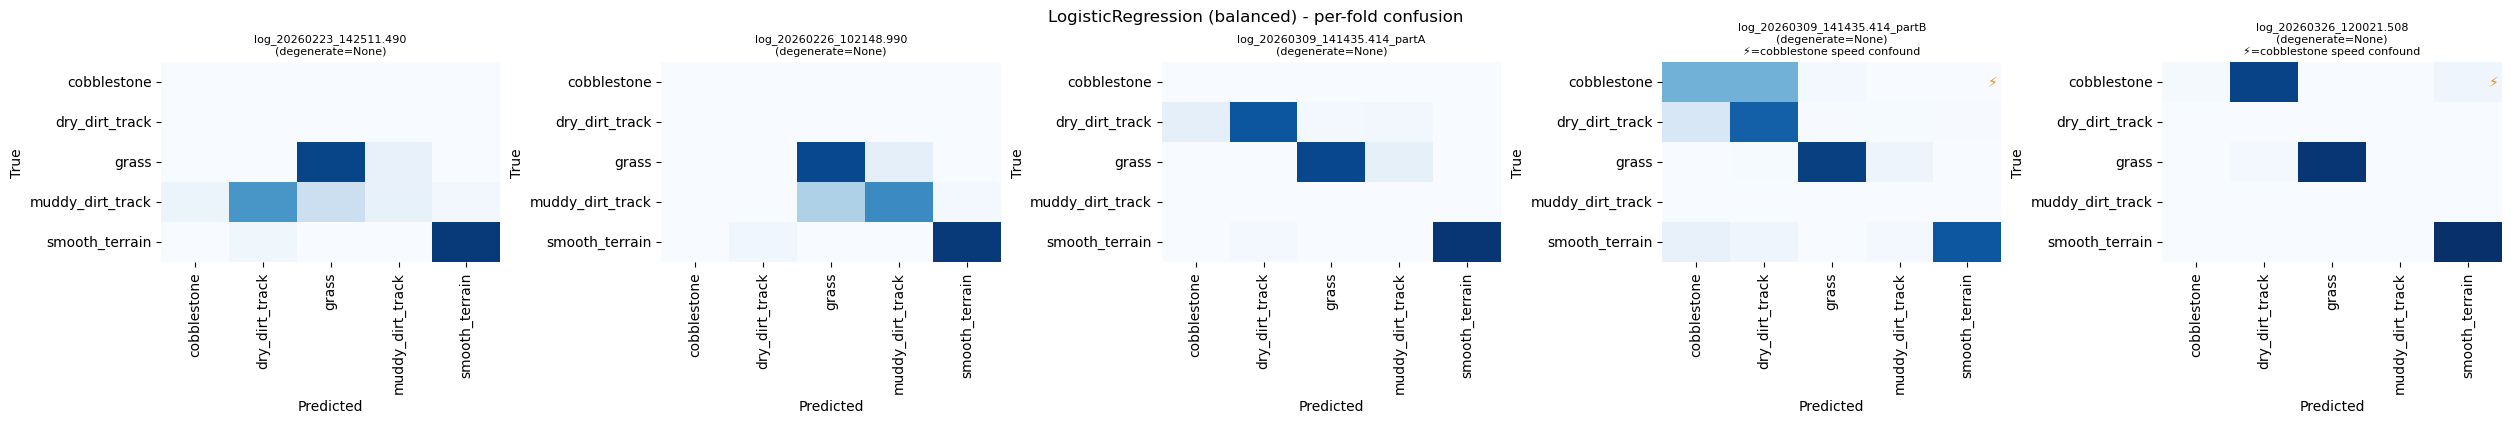

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_logisticregression_per_fold.png


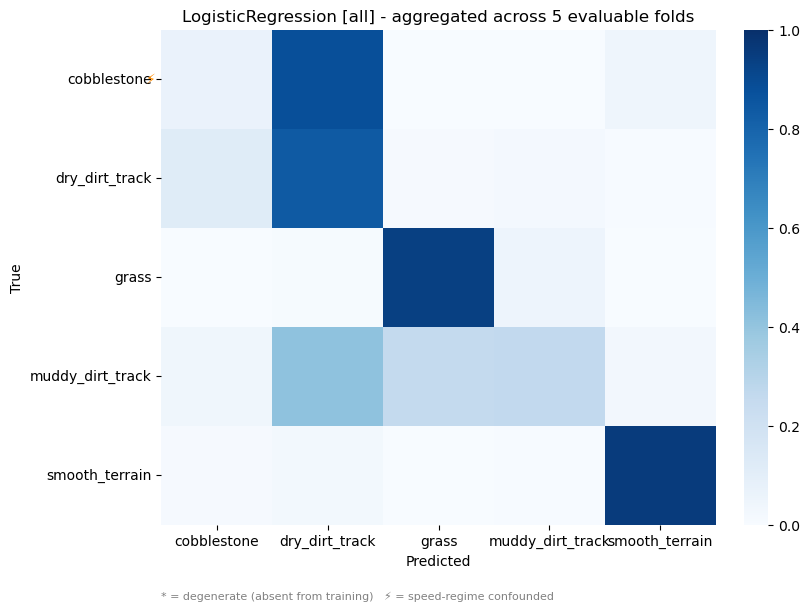

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_logisticregression_all.png


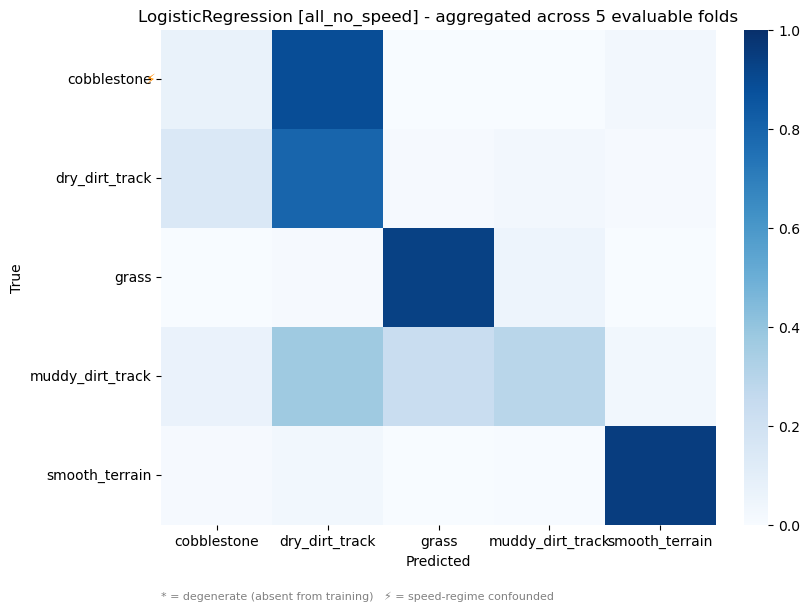

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_logisticregression_all_no_speed.png


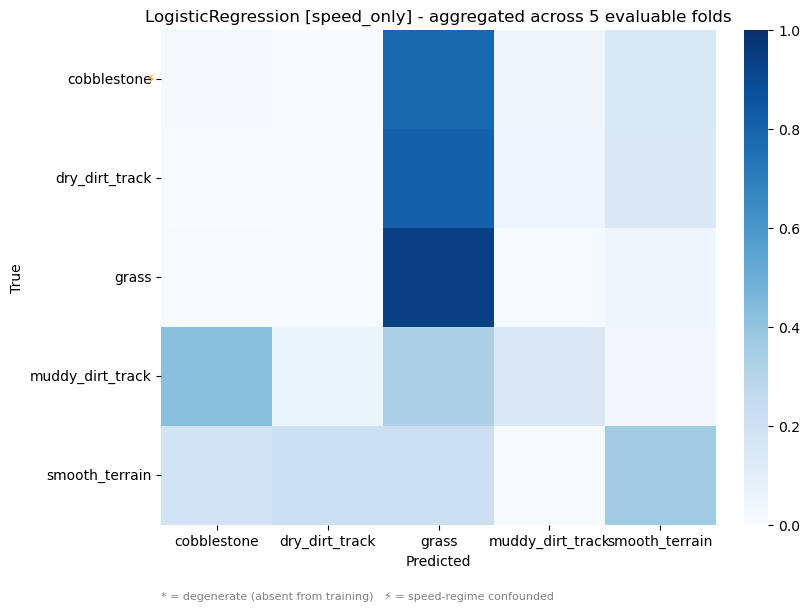

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_logisticregression_speed_only.png


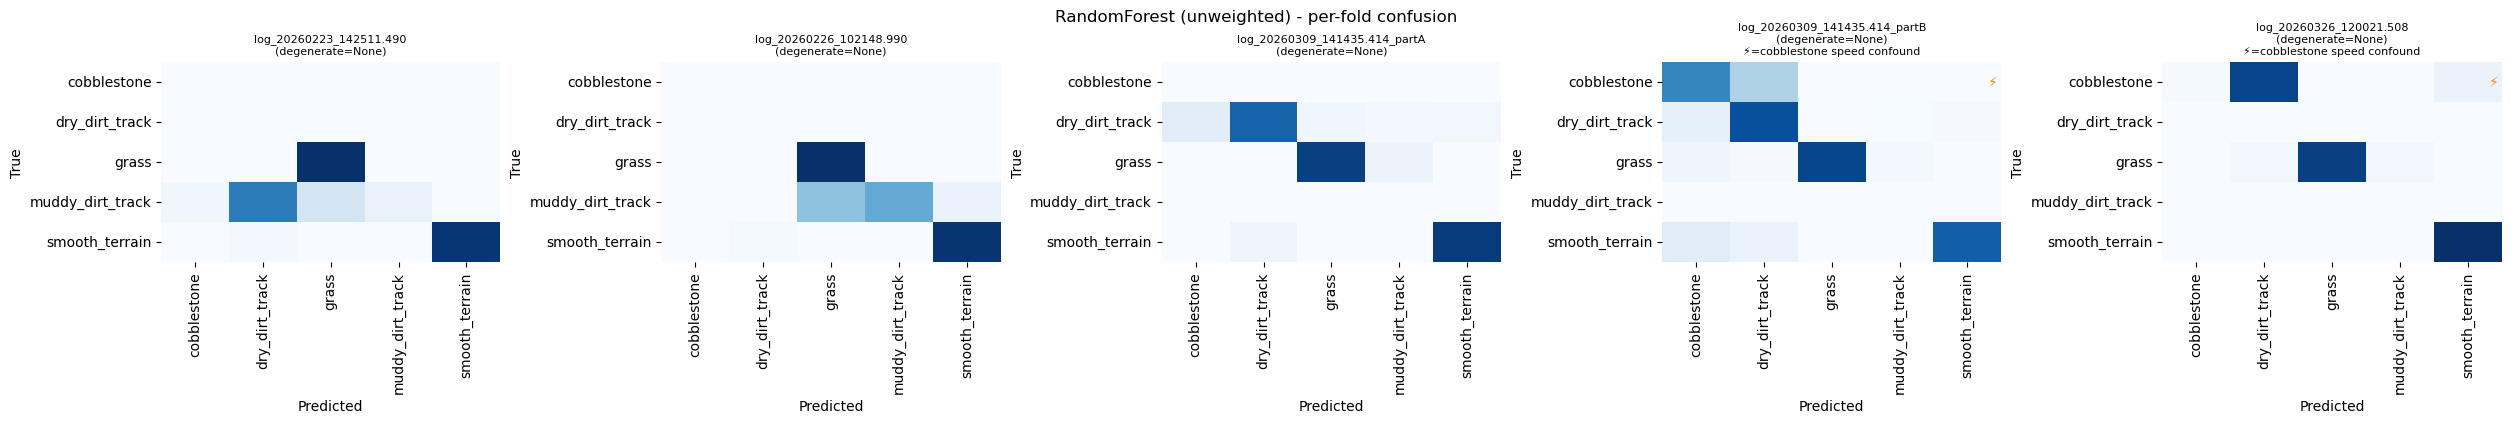

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_randomforest_per_fold.png


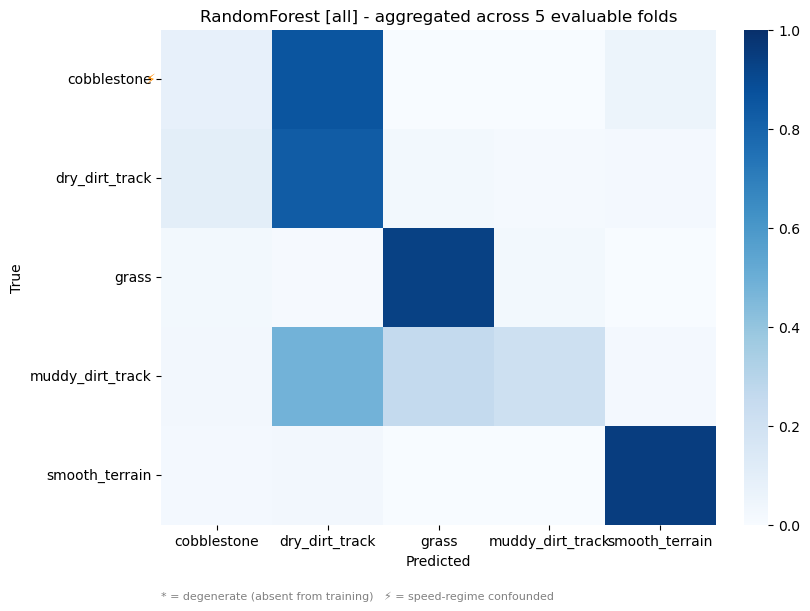

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_randomforest_all.png


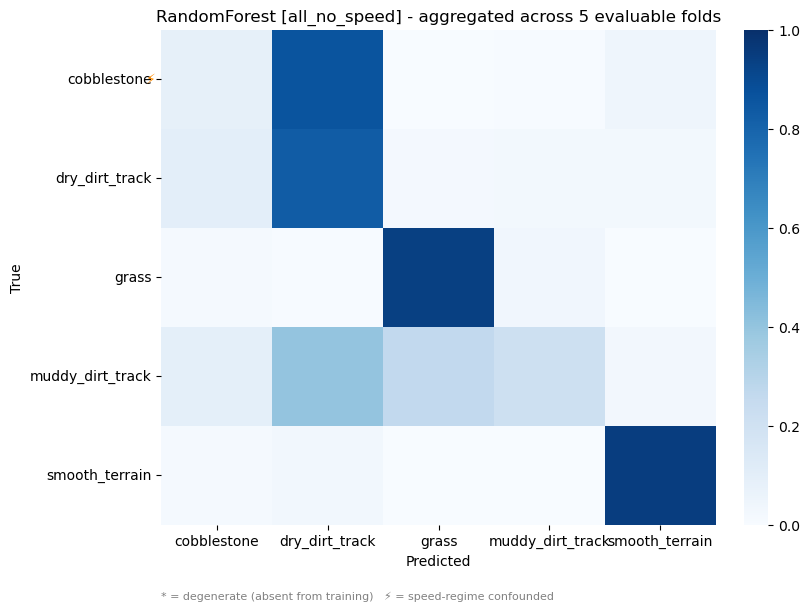

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_randomforest_all_no_speed.png


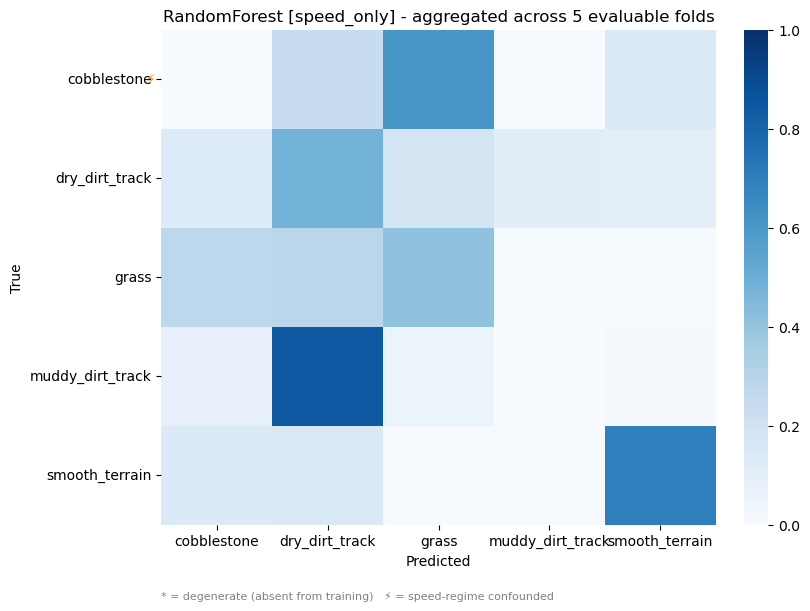

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_randomforest_speed_only.png


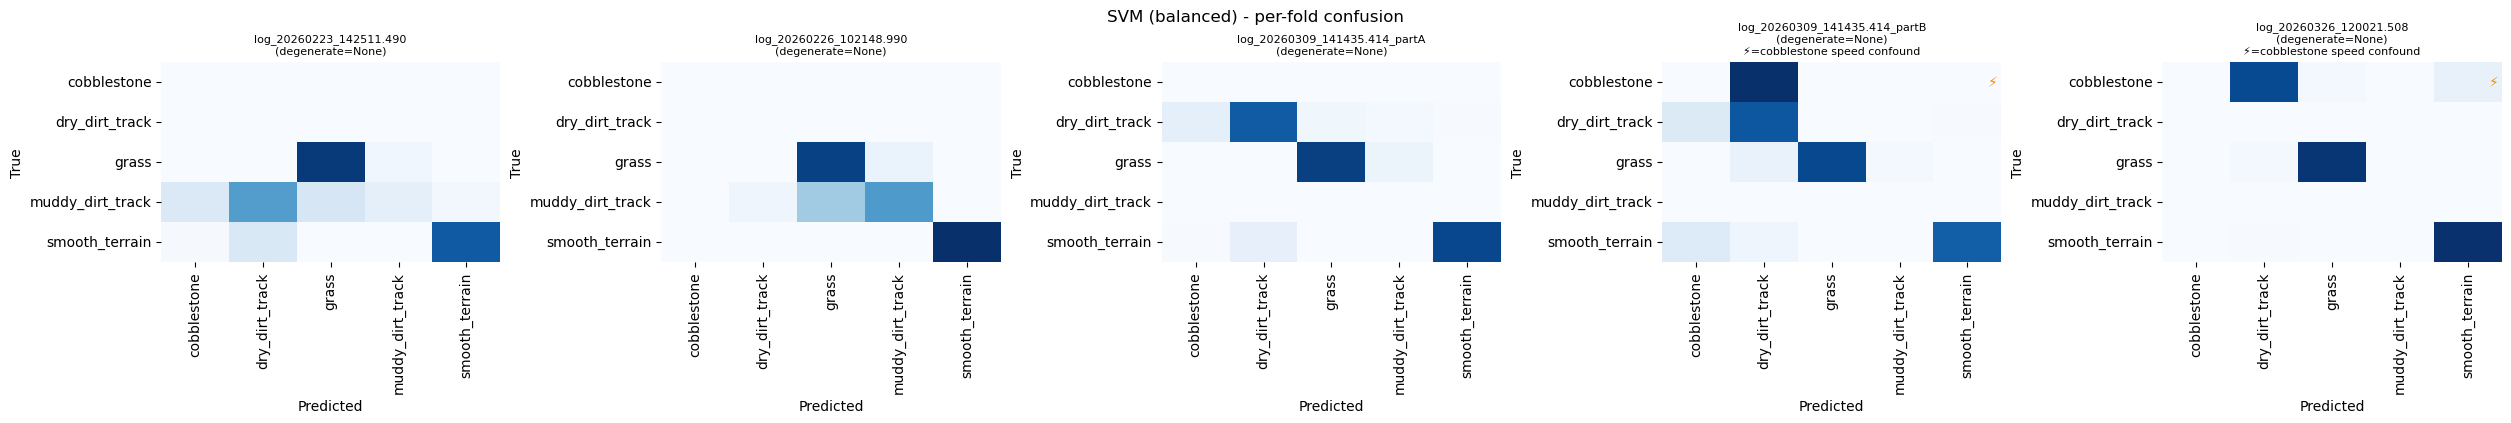

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_svm_per_fold.png


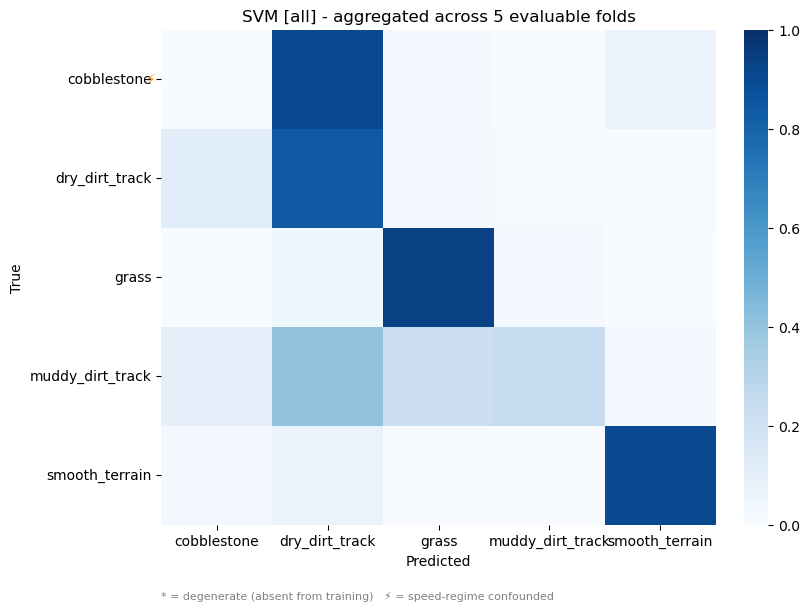

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_svm_all.png


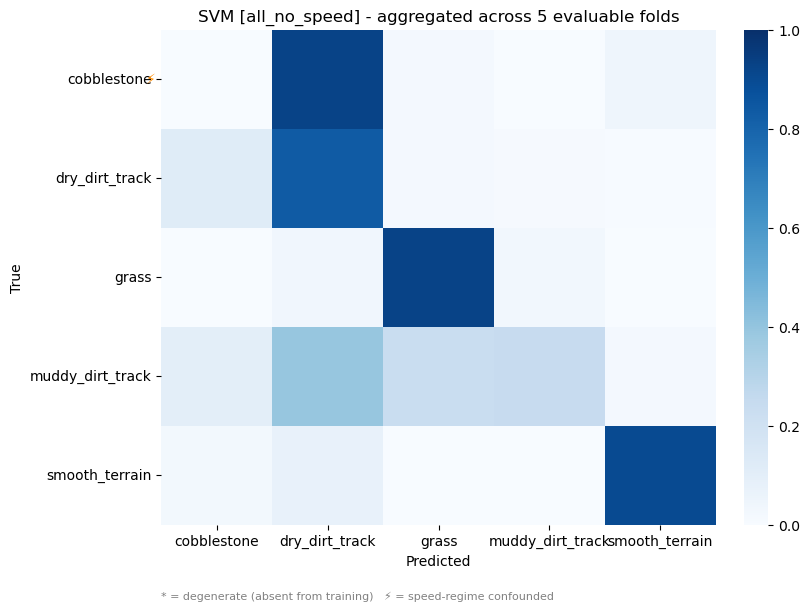

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_svm_all_no_speed.png


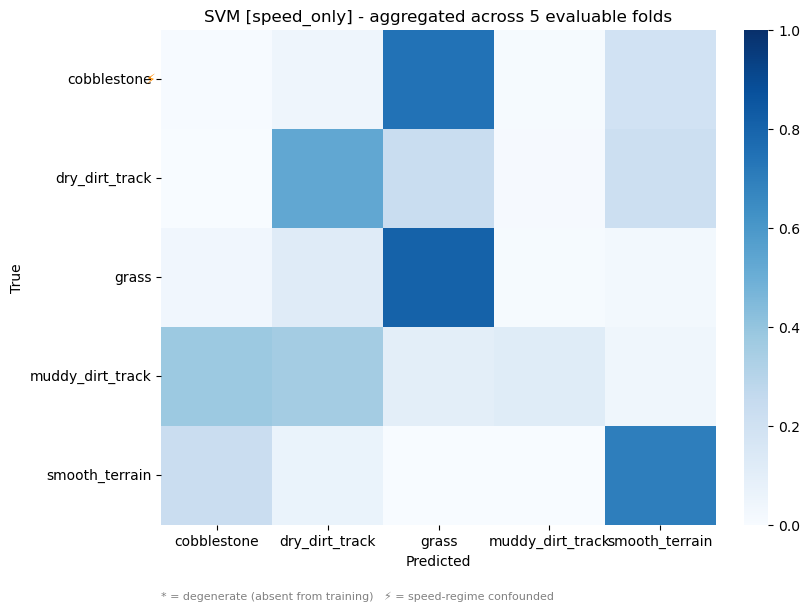

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_svm_speed_only.png


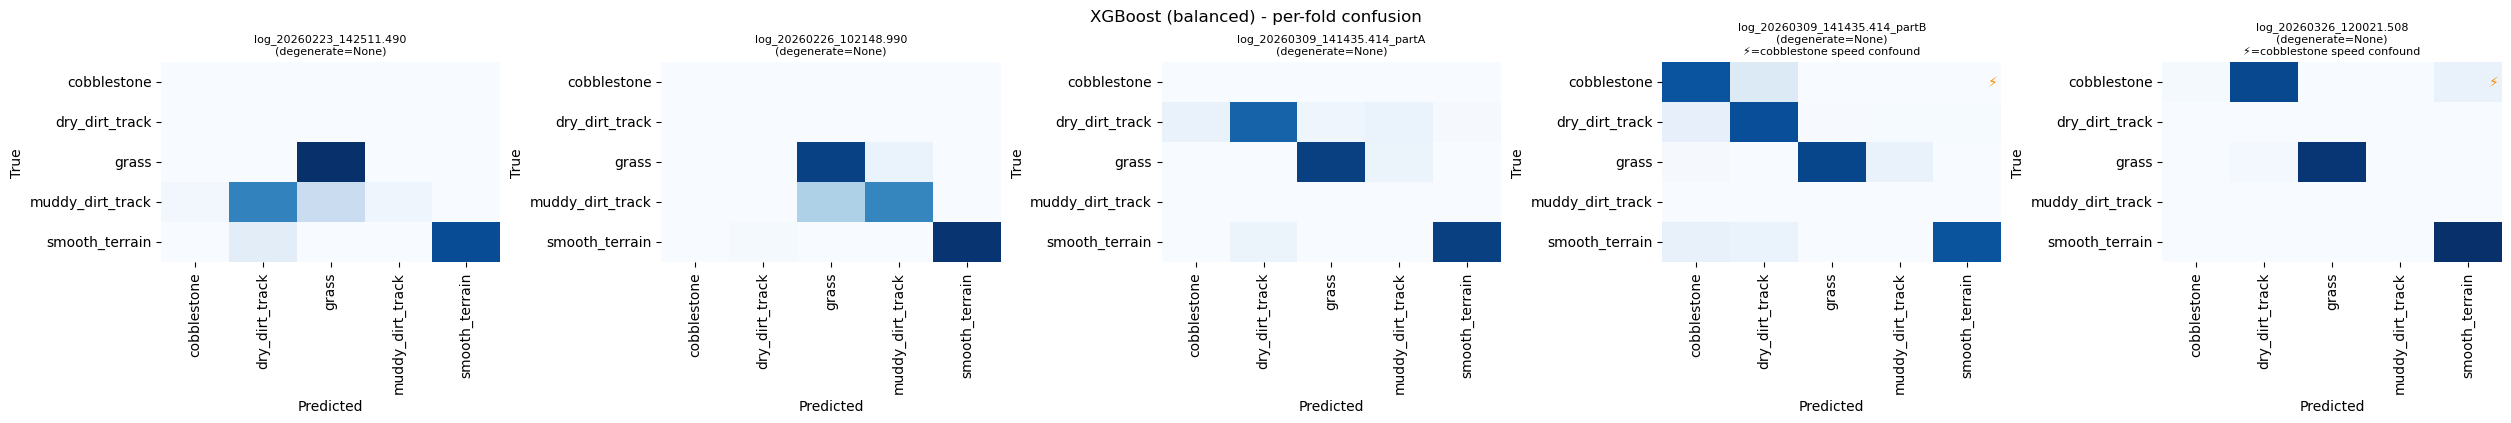

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_xgboost_per_fold.png


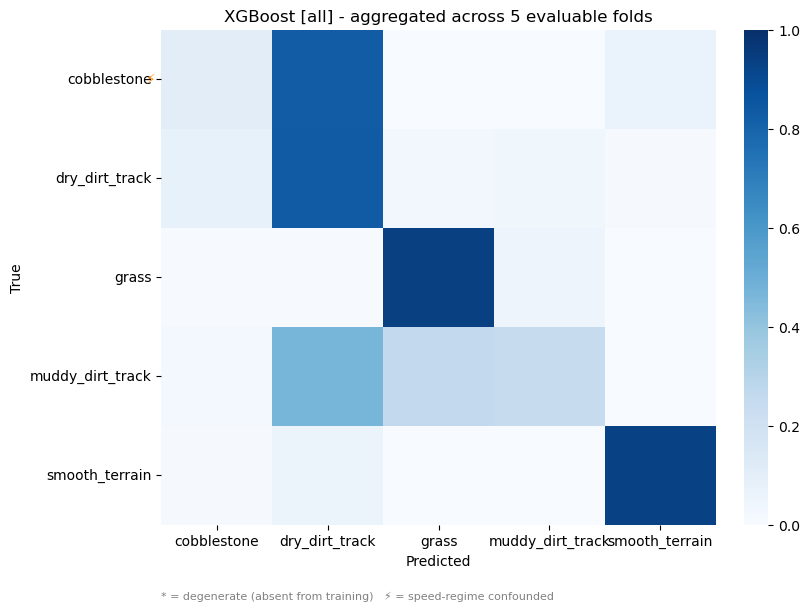

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_xgboost_all.png


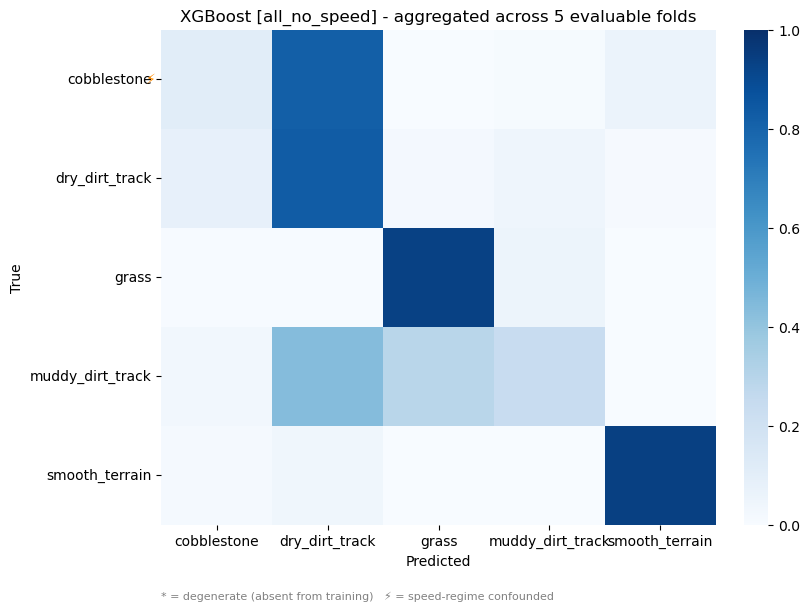

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_xgboost_all_no_speed.png


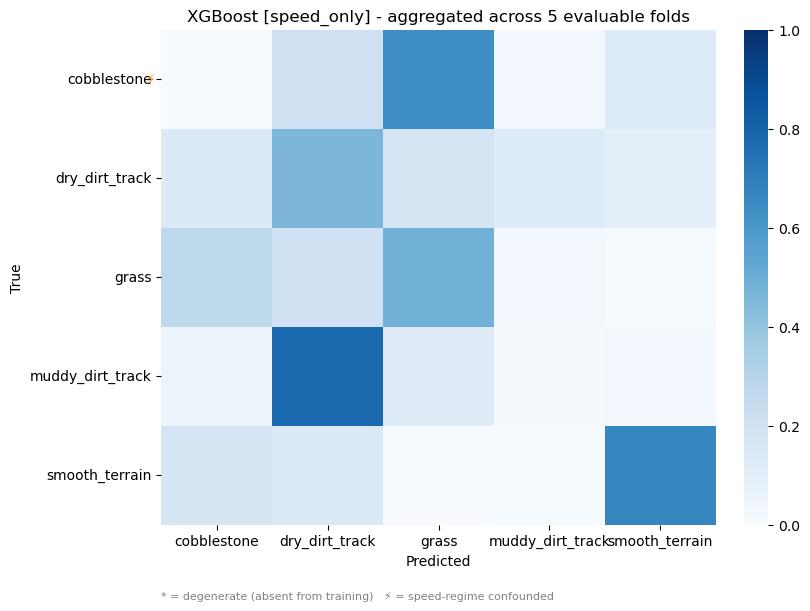

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/confusion_matrix_xgboost_speed_only.png


In [9]:


def plot_aggregated_confusion(model_name: str, imbalance: str, feature_set_name: str, filename_suffix: str) -> None:
    recs = [
        r
        for r in confusion_records
        if r["model"] == model_name and r["feature_set"] == feature_set_name and r["imbalance"] == imbalance
    ]
    if not recs:
        warnings.warn(f"No confusion records for {model_name} ({imbalance}, {feature_set_name}).")
        return

    agg_raw = np.zeros((len(LABEL_ORDER), len(LABEL_ORDER)), dtype=int)
    agg_row_support = np.zeros(len(LABEL_ORDER), dtype=int)
    evaluable_fold_count = 0

    for test_run in run_ids:
        rec = next((r for r in recs if r["test_run"] == test_run), None)
        if rec is None:
            continue
        cm_raw = confusion_matrix(rec["y_true"], rec["y_pred"], labels=LABEL_ORDER)
        degenerate_classes = rec["degenerate_classes"]
        if not degenerate_classes:
            agg_raw += cm_raw
            agg_row_support += cm_raw.sum(axis=1).astype(int)
            evaluable_fold_count += 1

    agg_norm = row_normalize(agg_raw)
    fig_agg, ax_agg = plt.subplots(figsize=(8, 6), constrained_layout=True)
    sns.heatmap(
        agg_norm,
        ax=ax_agg,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        cbar=True,
    )
    ax_agg.set_title(
        f"{model_name} [{feature_set_name}] - aggregated across {evaluable_fold_count} evaluable folds"
    )
    ax_agg.set_xlabel("Predicted")
    ax_agg.set_ylabel("True")

    for row_idx, cls_name in enumerate(LABEL_ORDER):
        support = int(agg_row_support[row_idx])
        if support < CLASS_SAMPLE_WARN_THRESHOLD:
            ax_agg.text(
                len(LABEL_ORDER) - 0.05,
                row_idx + 0.5,
                f"n={support}",
                ha="right",
                va="center",
                color="black",
                fontsize=9,
                bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none"},
            )

    all_confounded_classes = set()
    for fold_confounds in KNOWN_CONFOUNDED.values():
        all_confounded_classes.update(fold_confounds.keys())

    for row_idx, cls_name in enumerate(LABEL_ORDER):
        if cls_name in all_confounded_classes:
            ax_agg.text(
                -0.05,
                row_idx + 0.5,
                "⚡",
                ha="right",
                va="center",
                fontsize=10,
                color="darkorange",
            )

    ax_agg.text(
        0,
        -0.15,
        "* = degenerate (absent from training)   ⚡ = speed-regime confounded",
        transform=ax_agg.transAxes,
        fontsize=8,
        color="gray",
    )

    agg_path = REPORTS_DIR / f"confusion_matrix_{model_name.lower()}_{filename_suffix}.png"
    fig_agg.savefig(agg_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {agg_path}")


all_feature_summary = summary_df[summary_df["feature_set"] == "all"].copy()
if all_feature_summary.empty:
    raise RuntimeError("No all-feature summary rows found.")

best_imbalance_by_model: dict[str, str] = {}
for model_name in sorted(all_feature_summary["model"].unique().tolist()):
    sub = all_feature_summary[all_feature_summary["model"] == model_name]
    sub = sub.sort_values("macro_f1_mean", ascending=False)
    best_imbalance_by_model[model_name] = str(sub.iloc[0]["imbalance"])

print("Best imbalance per model (all features):")
print(best_imbalance_by_model)

for model_name, best_imbalance in best_imbalance_by_model.items():
    recs = [
        r
        for r in confusion_records
        if r["model"] == model_name and r["feature_set"] == "all" and r["imbalance"] == best_imbalance
    ]

    if not recs:
        warnings.warn(f"No confusion records for {model_name} ({best_imbalance}).")
        continue

    fig, axes = plt.subplots(1, len(run_ids), figsize=(5 * len(run_ids), 4), constrained_layout=True)
    if len(run_ids) == 1:
        axes = [axes]

    for idx, test_run in enumerate(run_ids):
        ax = axes[idx]
        rec = next((r for r in recs if r["test_run"] == test_run), None)
        if rec is None:
            ax.axis("off")
            ax.set_title(f"{test_run} (missing)")
            continue

        cm_raw = confusion_matrix(rec["y_true"], rec["y_pred"], labels=LABEL_ORDER)
        cm_norm = row_normalize(cm_raw)

        sns.heatmap(
            cm_norm,
            ax=ax,
            cmap="Blues",
            vmin=0,
            vmax=1,
            xticklabels=LABEL_ORDER,
            yticklabels=LABEL_ORDER,
            cbar=False,
        )

        degenerate_classes = rec["degenerate_classes"]
        for deg_cls in degenerate_classes:
            if deg_cls in LABEL_ORDER:
                d_idx = LABEL_ORDER.index(deg_cls)
                ax.axhspan(d_idx, d_idx + 1, color="lightgray", alpha=0.35)
                ax.axvspan(d_idx, d_idx + 1, color="lightgray", alpha=0.20)
                ax.text(d_idx + 0.5, d_idx + 0.5, "*", ha="center", va="center", color="black", fontsize=14)

        title_suffix = ""
        confounded_for_fold = KNOWN_CONFOUNDED.get(test_run, {})
        for conf_cls, _ in confounded_for_fold.items():
            if conf_cls in LABEL_ORDER:
                c_idx = LABEL_ORDER.index(conf_cls)
                ax.text(
                    len(LABEL_ORDER) - 0.05,
                    c_idx + 0.5,
                    "⚡",
                    ha="right",
                    va="center",
                    fontsize=10,
                    color="darkorange",
                )
                title_suffix = f"\n⚡={conf_cls} speed confound"

        ax.set_title(
            f"{test_run}\n(degenerate={degenerate_classes if degenerate_classes else 'None'}){title_suffix}",
            fontsize=8,
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    per_fold_path = REPORTS_DIR / f"confusion_matrix_{model_name.lower()}_per_fold.png"
    fig.suptitle(f"{model_name} ({best_imbalance}) - per-fold confusion", y=1.02)
    fig.savefig(per_fold_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {per_fold_path}")

    plot_aggregated_confusion(
        model_name=model_name,
        imbalance=best_imbalance,
        feature_set_name="all",
        filename_suffix="all",
    )

    for ablation_feature_set in ["all_no_speed", "speed_only"]:
        if ablation_feature_set in set(summary_df["feature_set"].unique()):
            plot_aggregated_confusion(
                model_name=model_name,
                imbalance=best_imbalance,
                feature_set_name=ablation_feature_set,
                filename_suffix=ablation_feature_set,
            )

## Cell 7: Per-Class Metrics Breakdown

Compute per-class precision/recall/F1 summaries by model (best imbalance, all-features setting), report fold coverage per class, and flag low-coverage estimates.

In [10]:
per_class_df = pd.DataFrame(per_class_rows)
if per_class_df.empty:
    raise RuntimeError("Per-class metrics were not collected.")


# Determine which classes are confounded across any fold
all_confounded_classes = set()
for fold_confounds in KNOWN_CONFOUNDED.values():
    all_confounded_classes.update(fold_confounds.keys())

for model_name, best_imbalance in best_imbalance_by_model.items():
    sub = per_class_df[
        (per_class_df["model"] == model_name)
        & (per_class_df["feature_set"] == "all")
        & (per_class_df["imbalance"] == best_imbalance)
    ].copy()

    rows = []
    for cls_name in LABEL_ORDER:
        cls_sub = sub[sub["class"] == cls_name]
        f1_vals = cls_sub["f1"].dropna()
        folds_eval = int(f1_vals.shape[0])
        warn = "WARN" if folds_eval < len(run_ids) else ""
        rows.append(
            {
                "Class": cls_name,
                "Precision": fmt_mean_std(cls_sub["precision"]),
                "Recall": fmt_mean_std(cls_sub["recall"]),
                "F1": fmt_mean_std(cls_sub["f1"]),
                "F1 median": float(f1_vals.median()) if not f1_vals.empty else np.nan,
                "F1 min": float(f1_vals.min()) if not f1_vals.empty else np.nan,
                "F1 max": float(f1_vals.max()) if not f1_vals.empty else np.nan,
                "Folds evaluated": f"{folds_eval}/{len(run_ids)}",
                "Flag": warn,
                "Confound": "speed ⚡" if cls_name in all_confounded_classes else "",
                "precision_mean": cls_sub["precision"].mean(skipna=True),
                "precision_std": cls_sub["precision"].std(ddof=0, skipna=True),
                "recall_mean": cls_sub["recall"].mean(skipna=True),
                "recall_std": cls_sub["recall"].std(ddof=0, skipna=True),
                "f1_mean": cls_sub["f1"].mean(skipna=True),
                "f1_std": cls_sub["f1"].std(ddof=0, skipna=True),
                "f1_median": float(f1_vals.median()) if not f1_vals.empty else np.nan,
                "f1_min": float(f1_vals.min()) if not f1_vals.empty else np.nan,
                "f1_max": float(f1_vals.max()) if not f1_vals.empty else np.nan,
                "folds_evaluated": folds_eval,
            }
        )

    pretty_table = pd.DataFrame(rows)[
        [
            "Class",
            "Precision",
            "Recall",
            "F1",
            "F1 median",
            "F1 min",
            "F1 max",
            "Folds evaluated",
            "Flag",
            "Confound",
        ]
    ]
    print(f"\nPer-class metrics for {model_name} ({best_imbalance}, all features):")
    print(pretty_table.to_string(index=False))

    print("NOTE: Classes with fewer than 4 evaluable folds are exploratory only.")
    print("NOTE: ⚡ = cobblestone speed confound. Run 3 is high-speed, run 4 is low-speed.")
    print("      Both cobblestone folds have opposite speed regimes - metrics are unreliable in both directions.")

    export_df = pd.DataFrame(rows)[
        [
            "Class",
            "precision_mean",
            "precision_std",
            "recall_mean",
            "recall_std",
            "f1_mean",
            "f1_std",
            "f1_median",
            "f1_min",
            "f1_max",
            "folds_evaluated",
            "Flag",
            "Confound",
        ]
    ]
    export_path = RESULTS_DIR / f"per_class_metrics_{model_name.lower()}.csv"
    export_df.to_csv(export_path, index=False)
    print(f"Saved: {export_path}")


Per-class metrics for LogisticRegression (balanced, all features):
           Class       Precision          Recall              F1  F1 median   F1 min   F1 max Folds evaluated Flag Confound
     cobblestone 0.632 +/- 0.368 0.253 +/- 0.234 0.190 +/- 0.153   0.189947 0.037037 0.342857             2/5 WARN  speed ⚡
  dry_dirt_track 0.939 +/- 0.049 0.833 +/- 0.019 0.883 +/- 0.033   0.882867 0.850202 0.915531             2/5 WARN         
           grass 0.824 +/- 0.180 0.933 +/- 0.026 0.865 +/- 0.117   0.898551 0.666667 0.990099             5/5              
muddy_dirt_track 0.841 +/- 0.041 0.366 +/- 0.286 0.448 +/- 0.302   0.448394 0.146789 0.750000             2/5 WARN         
  smooth_terrain 0.970 +/- 0.031 0.951 +/- 0.052 0.959 +/- 0.026   0.969880 0.911504 0.987531             5/5              
NOTE: Classes with fewer than 4 evaluable folds are exploratory only.
NOTE: ⚡ = cobblestone speed confound. Run 3 is high-speed, run 4 is low-speed.
      Both cobblestone folds have oppos

## Cell 8: Feature Importance and Coefficients

Interpret model behavior using fold-fitted estimators only:
- RF/XGBoost: average `feature_importances_` across folds.
- LogisticRegression: coefficient heatmap across classes.

Important verification rule:
- Importances and coefficients are extracted from `pipeline.named_steps['clf']` immediately after each fold fit, not from any post-loop refit.

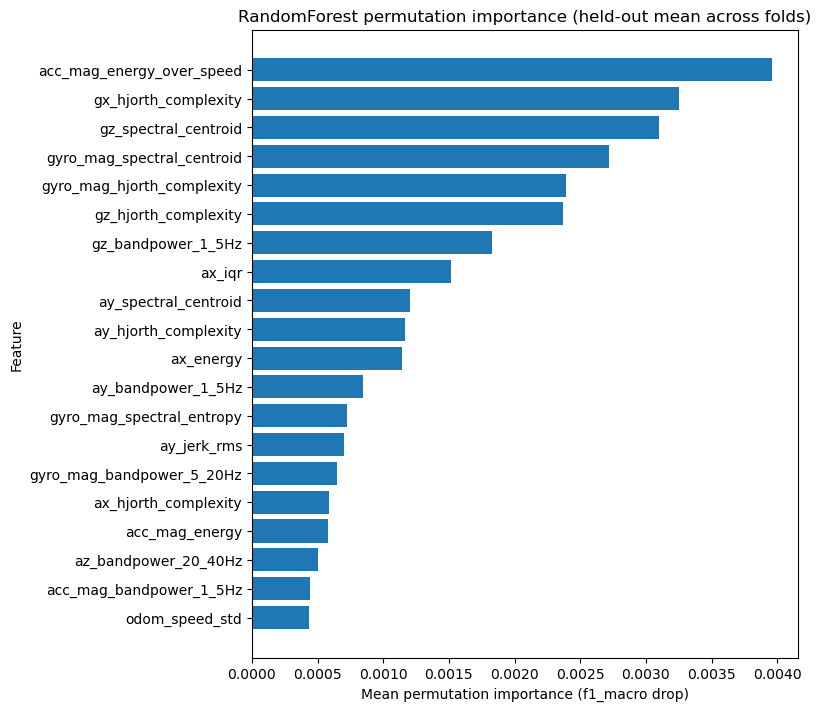

Top 10 permutation features for RandomForest:
['acc_mag_energy_over_speed', 'gx_hjorth_complexity', 'gz_spectral_centroid', 'gyro_mag_spectral_centroid', 'gyro_mag_hjorth_complexity', 'gz_hjorth_complexity', 'gz_bandpower_1_5Hz', 'ax_iqr', 'ay_spectral_centroid', 'ay_hjorth_complexity']
Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/feature_importance_permutation_randomforest.png


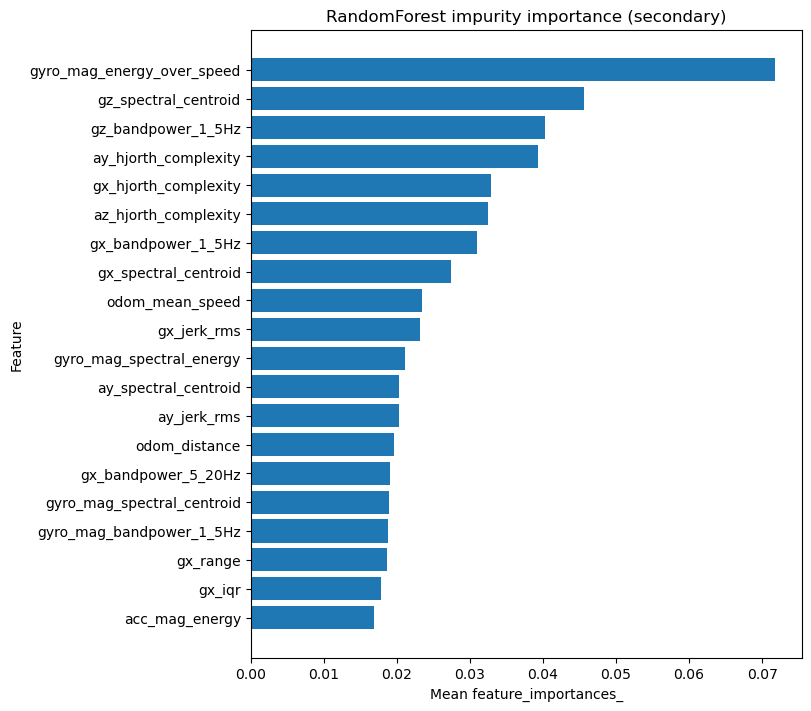

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/feature_importance_impurity_randomforest.png


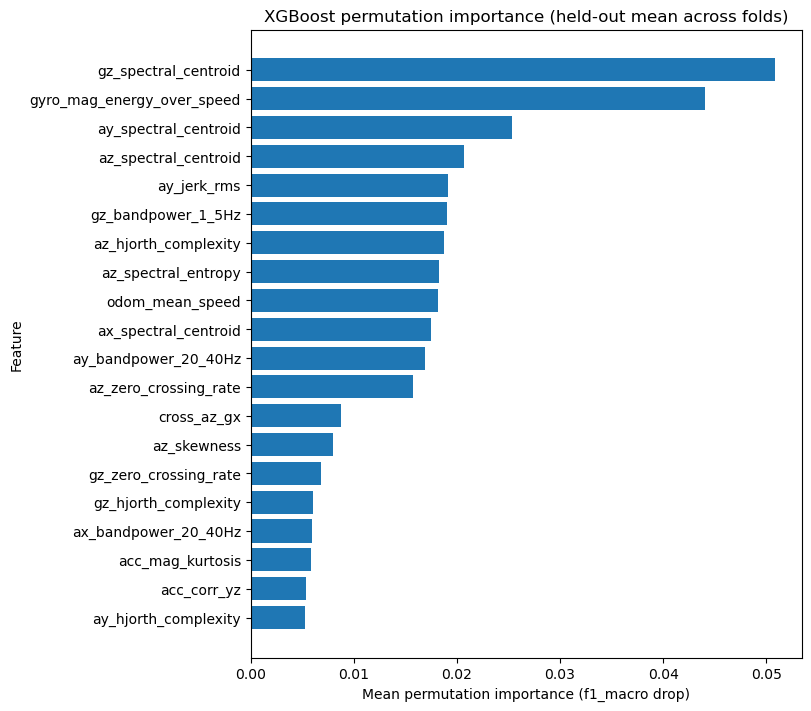

Top 10 permutation features for XGBoost:
['gz_spectral_centroid', 'gyro_mag_energy_over_speed', 'ay_spectral_centroid', 'az_spectral_centroid', 'ay_jerk_rms', 'gz_bandpower_1_5Hz', 'az_hjorth_complexity', 'az_spectral_entropy', 'odom_mean_speed', 'ax_spectral_centroid']
Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/feature_importance_permutation_xgboost.png


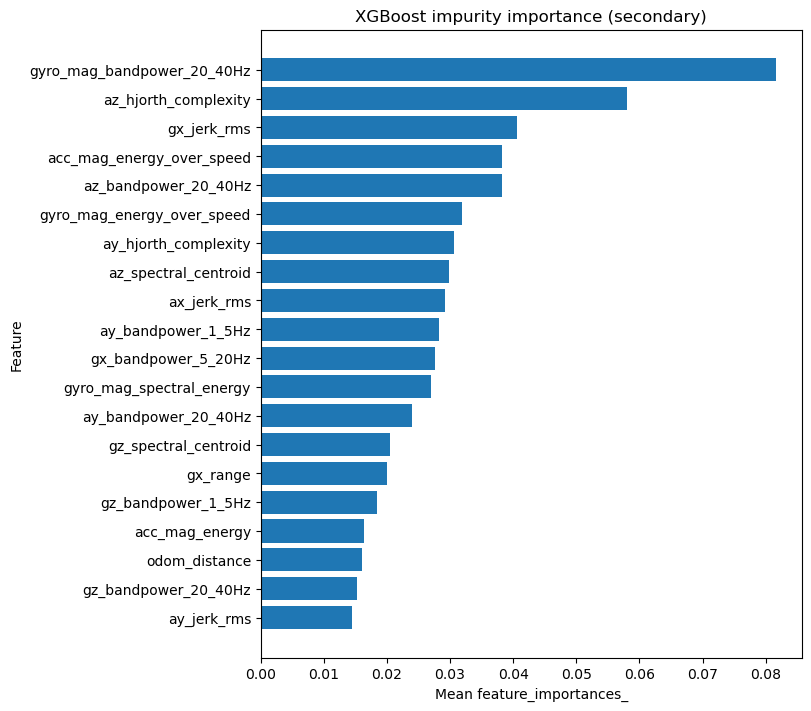

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/feature_importance_impurity_xgboost.png


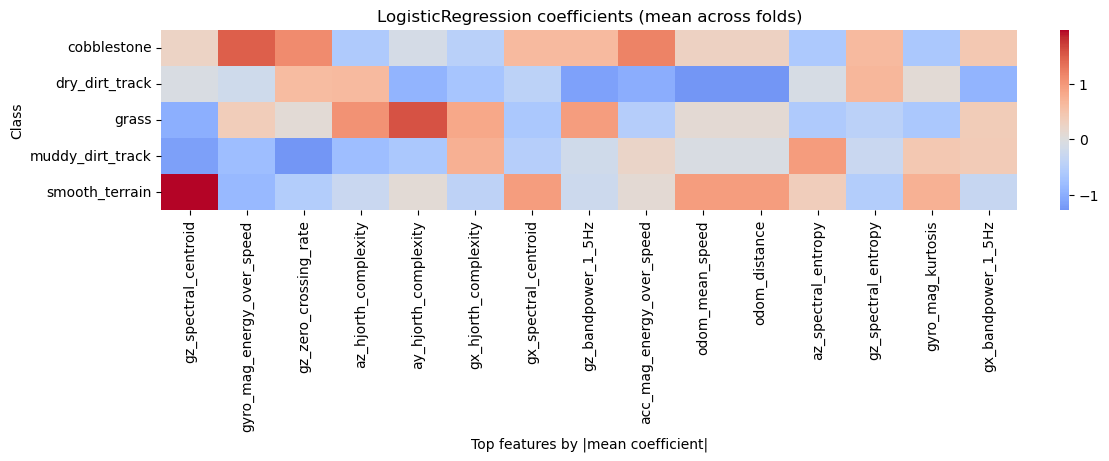

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/lr_coefficients.png

Top-10 overlap between RandomForest and XGBoost (permutation-robust features):
['ay_spectral_centroid', 'gz_bandpower_1_5Hz', 'gz_spectral_centroid']


In [11]:
top10_by_model: dict[str, list[str]] = {}

for model_name in ["RandomForest", "XGBoost"]:
    imbalance = best_imbalance_by_model.get(model_name)
    if imbalance is None:
        continue

    key = (model_name, "all", imbalance)

    # Primary: permutation importance on held-out folds.
    fold_perm_importances = permutation_importance_store.get(key, [])
    if fold_perm_importances:
        perm_df = pd.concat(fold_perm_importances, axis=1).T.fillna(0.0)
        perm_mean = perm_df.mean(axis=0).sort_values(ascending=False)

        top20_perm = perm_mean.head(20).sort_values(ascending=True)
        fig_perm, ax_perm = plt.subplots(figsize=(8, 7), constrained_layout=True)
        ax_perm.barh(top20_perm.index, top20_perm.values)
        ax_perm.set_title(f"{model_name} permutation importance (held-out mean across folds)")
        ax_perm.set_xlabel("Mean permutation importance (f1_macro drop)")
        ax_perm.set_ylabel("Feature")

        out_perm = REPORTS_DIR / f"feature_importance_permutation_{model_name.lower()}.png"
        fig_perm.savefig(out_perm, dpi=200, bbox_inches="tight")
        plt.show()

        top10_by_model[model_name] = perm_mean.head(10).index.tolist()
        print(f"Top 10 permutation features for {model_name}:")
        print(top10_by_model[model_name])
        print(f"Saved: {out_perm}")
    else:
        warnings.warn(f"No stored held-out permutation importances for {key}.")

    # Secondary: impurity-based importances from fitted trees.
    fold_impurity_importances = feature_importance_store.get(key, [])
    if fold_impurity_importances:
        imp_df = pd.concat(fold_impurity_importances, axis=1).T.fillna(0.0)
        imp_mean = imp_df.mean(axis=0).sort_values(ascending=False)

        top20_imp = imp_mean.head(20).sort_values(ascending=True)
        fig_imp, ax_imp = plt.subplots(figsize=(8, 7), constrained_layout=True)
        ax_imp.barh(top20_imp.index, top20_imp.values)
        ax_imp.set_title(f"{model_name} impurity importance (secondary)")
        ax_imp.set_xlabel("Mean feature_importances_")
        ax_imp.set_ylabel("Feature")

        out_imp = REPORTS_DIR / f"feature_importance_impurity_{model_name.lower()}.png"
        fig_imp.savefig(out_imp, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_imp}")
    else:
        warnings.warn(f"No stored impurity importances for {key}.")

lr_imbalance = best_imbalance_by_model.get("LogisticRegression")
if lr_imbalance is not None:
    lr_key = ("all", lr_imbalance)
    lr_folds = lr_coef_store.get(lr_key, [])

    if lr_folds:
        aligned = [coef.reindex(index=LABEL_ORDER, columns=feature_cols_all).fillna(0.0) for coef in lr_folds]
        stack = np.stack([a.to_numpy(dtype=float) for a in aligned], axis=0)
        mean_coef = np.nanmean(stack, axis=0)
        mean_coef_df = pd.DataFrame(mean_coef, index=LABEL_ORDER, columns=feature_cols_all)

        top15 = mean_coef_df.abs().mean(axis=0).sort_values(ascending=False).head(15).index.tolist()
        plot_df = mean_coef_df[top15]

        fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
        sns.heatmap(plot_df, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("LogisticRegression coefficients (mean across folds)")
        ax.set_xlabel("Top features by |mean coefficient|")
        ax.set_ylabel("Class")

        lr_out = REPORTS_DIR / "lr_coefficients.png"
        fig.savefig(lr_out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {lr_out}")

if "RandomForest" in top10_by_model and "XGBoost" in top10_by_model:
    overlap = sorted(set(top10_by_model["RandomForest"]).intersection(set(top10_by_model["XGBoost"])))
    print("\nTop-10 overlap between RandomForest and XGBoost (permutation-robust features):")
    print(overlap if overlap else "None")

## Cell 9: Optional Hyperparameter Tuning (Guarded)

When enabled, this cell performs `RandomizedSearchCV` with `GroupKFold` (`groups=run_id`) so run boundaries remain intact during tuning.

This cell only reports and saves best parameters. It does not re-run baseline evaluation.

In [12]:
if RUN_OPTIONAL_TUNING:
    print("Running light tuning pass (reduced search budget; prioritize split diagnostics/ablations).")
    param_grids = {
        "LogisticRegression": {"clf__C": [0.1, 1.0, 10.0]},
        "RandomForest": {
            "clf__n_estimators": [200, 300, 500],
            "clf__max_depth": [None, 10, 20],
            "clf__min_samples_leaf": [1, 2, 4],
        },
        "XGBoost": {
            "clf__n_estimators": [200, 300, 500],
            "clf__max_depth": [3, 6],
            "clf__learning_rate": [0.03, 0.1, 0.2],
            "clf__subsample": [0.8, 1.0],
        },
        "SVM": {
            "clf__C": [0.1, 1.0, 10.0, 100.0],
            "clf__gamma": ["scale", "auto"],
        },
    }

    X_tune = df[feature_cols_all].copy()
    y_tune = df[LABEL_COL].astype(str).to_numpy()
    groups = df[RUN_COL].astype(str).to_numpy()

    le_tune = LabelEncoder()
    y_tune_enc = le_tune.fit_transform(y_tune)

    base_models = make_base_models(RANDOM_STATE)
    best_params = {}

    for model_name, pipe in base_models.items():
        print(f"Tuning {model_name}...")
        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_grids[model_name],
            n_iter=10,
            scoring="f1_macro",
            cv=GroupKFold(n_splits=4),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
        )

        # Encode labels for all models so XGBoost compatibility is guaranteed.
        search.fit(X_tune, y_tune_enc, groups=groups)
        best_params[model_name] = search.best_params_

        print(f"Best params for {model_name}: {search.best_params_}")

    tune_out = RESULTS_DIR / "tuning_best_params.json"
    with tune_out.open("w", encoding="utf-8") as f:
        json.dump(best_params, f, indent=2)

    print(f"Saved tuning params: {tune_out}")
else:
    print("RUN_OPTIONAL_TUNING is False. Skipping Cell 9.")

Running light tuning pass (reduced search budget; prioritize split diagnostics/ablations).
Tuning LogisticRegression...


/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params for LogisticRegression: {'clf__C': 0.1}
Tuning RandomForest...
Best params for RandomForest: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_depth': 10}
Tuning XGBoost...


/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
10 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/pratyush/miniforge3/envs/ricb

Best params for XGBoost: {'clf__subsample': 1.0, 'clf__n_estimators': 500, 'clf__max_depth': 6, 'clf__learning_rate': 0.2}
Tuning SVM...


/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params for SVM: {'clf__gamma': 'scale', 'clf__C': 0.1}
Saved tuning params: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/tuning_best_params.json


## Cell 10: Final Retrain + Summary

If enabled, this cell retrains the selected best model on the full dataset, saves artifacts, and prints the final thesis-style summary.

Caveat: retrained full-data model is for deployment packaging; LORO-CV metrics remain the only valid performance estimate.

In [13]:
best_model_name = None
best_feature_set = None
best_macro_f1 = np.nan
best_imbalance = None

best_mean_row = None
best_robust_row = None
best_robustness_score = np.nan
best_worst_fold_macro_f1 = np.nan

if RUN_RETRAIN_BEST:
    candidates = summary_df[(summary_df["feature_set"] == "all") & (summary_df["imbalance"] == "balanced")].copy()
    if candidates.empty:
        candidates = summary_df[summary_df["feature_set"] == "all"].copy()

    if candidates.empty:
        raise RuntimeError("No candidates available for final retraining.")

    best_mean_row = candidates.sort_values("macro_f1_mean", ascending=False).iloc[0]

    robust_candidates = candidates[candidates["worst_fold_macro_f1"] >= MIN_WORST_FOLD_MACRO_F1].copy()
    if robust_candidates.empty:
        warnings.warn(
            f"No candidate meets worst_fold_macro_f1 >= {MIN_WORST_FOLD_MACRO_F1:.2f}. "
            "Falling back to robustness ranking across all candidates."
        )
        robust_candidates = candidates.copy()

    best_robust_row = robust_candidates.sort_values(
        ["robustness_score", "macro_f1_mean"],
        ascending=False,
    ).iloc[0]

    best_model_name = str(best_robust_row["model"])
    best_feature_set = str(best_robust_row["feature_set"])
    best_imbalance = str(best_robust_row["imbalance"])
    best_macro_f1 = float(best_robust_row["macro_f1_mean"])
    best_robustness_score = float(best_robust_row["robustness_score"])
    best_worst_fold_macro_f1 = float(best_robust_row["worst_fold_macro_f1"])

    selected_variant = next(
        v
        for v in model_variants
        if v["base_model"] == best_model_name and v["imbalance"] == best_imbalance
    )

    final_pipeline = clone(selected_variant["pipeline"])
    final_feature_cols = feature_cols_all if best_feature_set == "all" else feature_cols_mi
    X_full = df[final_feature_cols].copy()
    y_full = df[LABEL_COL].astype(str).to_numpy()

    final_label_encoder = None
    fit_kwargs = {}

    if bool(selected_variant["requires_encoded_labels"]):
        final_label_encoder = LabelEncoder()
        y_full_enc = final_label_encoder.fit_transform(y_full)
        if bool(selected_variant["needs_sample_weight"]):
            fit_kwargs["clf__sample_weight"] = compute_sample_weight("balanced", y_full_enc)
        final_pipeline.fit(X_full, y_full_enc, **fit_kwargs)
    else:
        final_pipeline.fit(X_full, y_full)

    final_bundle = {
        "pipeline": final_pipeline,
        "label_encoder": final_label_encoder,
        "feature_columns": final_feature_cols,
        "label_order": LABEL_ORDER,
        "model": best_model_name,
        "imbalance": best_imbalance,
        "selection_rule": "robustness_score with worst-fold threshold",
    }

    final_model_path = MODELS_DIR / f"final_{best_model_name.lower()}.pkl"
    joblib.dump(final_bundle, final_model_path)

    metadata = {
        "model_name": best_model_name,
        "feature_set": best_feature_set,
        "imbalance": best_imbalance,
        "feature_columns": final_feature_cols,
        "label_order": LABEL_ORDER,
        "training_date": datetime.now(timezone.utc).isoformat(),
        "macro_f1_loro_cv": best_macro_f1,
        "robustness_score": best_robustness_score,
        "worst_fold_macro_f1": best_worst_fold_macro_f1,
        "selection_threshold_worst_fold_macro_f1": MIN_WORST_FOLD_MACRO_F1,
    }

    metadata_path = MODELS_DIR / "final_model_metadata.json"
    with metadata_path.open("w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print("This model is trained on all available data including the held-out test runs used during evaluation.")
    print("LORO-CV metrics are the only valid performance estimates. Do not re-evaluate this model on the same data.")
    print(f"Saved final model: {final_model_path}")
    print(f"Saved metadata: {metadata_path}")
else:
    print("RUN_RETRAIN_BEST is False. Skipping final retrain.")

print("\n" + "=" * 60)
print("BASELINE RESULTS SUMMARY")
print("=" * 60)
print(f"Split strategy : LORO-CV ({len(run_ids)} folds, leave-one-run-out)")
print(f"Feature sets   : {sorted(summary_df['feature_set'].unique().tolist())}")
print("Imbalance      : balanced vs unweighted comparison")

summary_print = summary_df.copy()
summary_print["macro_f1"] = summary_print.apply(
    lambda r: f"{r['macro_f1_mean']:.3f} +/- {r['macro_f1_std']:.3f}", axis=1
)
summary_print["acc"] = summary_print.apply(
    lambda r: f"{r['accuracy_mean']:.3f} +/- {r['accuracy_std']:.3f}", axis=1
)
summary_print["folds"] = summary_print["evaluable_folds"].astype(int).astype(str) + f"/{len(run_ids)}"
summary_print["robust"] = summary_print["robustness_score"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "NaN")
summary_print["worst_f1"] = summary_print["worst_fold_macro_f1"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "NaN")

print("Model | Features | Balanced | Macro F1 (mean+/-std) | Acc (mean+/-std) | Worst F1 | Robustness | Folds")
for _, row in summary_print.sort_values(["model", "feature_set", "imbalance"]).iterrows():
    balanced_txt = "yes" if row["imbalance"] == "balanced" else "no"
    print(
        f"{row['model']:20s} | {row['feature_set']:11s} | {balanced_txt:8s} | "
        f"{row['macro_f1']:21s} | {row['acc']:19s} | {row['worst_f1']:8s} | {row['robust']:10s} | {row['folds']}"
    )

print("\n* macro F1 computed over evaluable classes per fold.")
for cls, count in class_evaluable_fold_counts.items():
    if count < len(run_ids):
        reason = (
            "2/5 folds only (partA+partB split from original run 3)"
            if cls == "dry_dirt_track"
            else "limited run coverage"
        )
        print(f"  {cls}: {count}/{len(run_ids)} folds evaluable ({reason})")

all_confounded = set()
for v in KNOWN_CONFOUNDED.values():
    all_confounded.update(v.keys())
if all_confounded:
    print(f"\n⚡ Speed-regime confounded classes (evaluable but biased): {sorted(all_confounded)}")
    print("  cobblestone: run 3 = high-speed, run 4 = low-speed - both folds have opposite speed regimes.")

if best_mean_row is not None:
    print(
        "\nBest by mean macro F1: "
        f"{best_mean_row['model']} | {best_mean_row['feature_set']} | {best_mean_row['imbalance']} "
        f"| macro F1 = {best_mean_row['macro_f1_mean']:.3f}"
    )
if best_model_name is not None:
    print(
        "Best by robustness rule: "
        f"{best_model_name} | {best_feature_set} | {best_imbalance} "
        f"| macro F1 = {best_macro_f1:.3f} | worst fold F1 = {best_worst_fold_macro_f1:.3f} "
        f"| robustness = {best_robustness_score:.3f}"
    )

print("\nSaved:")
print(f"  {RESULTS_DIR / 'baseline_metrics_per_fold.csv'}")
print(f"  {RESULTS_DIR / 'baseline_metrics_summary.csv'}")
print(f"  {RESULTS_DIR / 'baseline_metrics_ranked_by_robustness.csv'}")
print(f"  {RESULTS_DIR / 'per_class_metrics_*.csv'}")
print(f"  {REPORTS_DIR / 'confusion_matrix_*.png'}")
print(f"  {REPORTS_DIR / 'feature_importance_*.png'}")
if best_model_name is not None:
    print(f"  {MODELS_DIR / ('final_' + best_model_name.lower() + '.pkl')}")

print("\nNext: 08_tuning.ipynb (set RUN_OPTIONAL_TUNING=True in Cell 9 first)")
print("=" * 60)

This model is trained on all available data including the held-out test runs used during evaluation.
LORO-CV metrics are the only valid performance estimates. Do not re-evaluate this model on the same data.
Saved final model: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/models/final_randomforest.pkl
Saved metadata: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/models/final_model_metadata.json

BASELINE RESULTS SUMMARY
Split strategy : LORO-CV (5 folds, leave-one-run-out)
Feature sets   : ['all', 'all_no_speed', 'speed_only', 'top_mi']
Imbalance      : balanced vs unweighted comparison
Model | Features | Balanced | Macro F1 (mean+/-std) | Acc (mean+/-std) | Worst F1 | Robustness | Folds
LogisticRegression   | all         | yes      | 0.760 +/- 0.122       | 0.743 +/- 0.164     | 0.594    | 0.699      | 5/5
LogisticRegression   | all         | no       | 0.754 +/- 0.112       | 0.737 +/- 0.160     | 0.609    | 0.699  